In [3]:
import numpy as np
import pandas as pd
import matplotlib
import torch
import torchvision

In [4]:
print(np.__version__)
print(pd.__version__)
print(matplotlib.__version__)
print(torch.__version__)
print(torchvision.__version__)

2.4.4
3.0.3
3.11.0
2.13.0
0.28.0


In [5]:
from  pathlib import Path

In [6]:
def count_jpeg(kind , disease):
    path = Path(f"./data/{kind}/{disease}/")
    count = sum (1 for p in path.iterdir() if p.is_file())
    return count

In [7]:
train_NORMAL_count = count_jpeg("train" , "NORMAL")
train_NORMAL_count

1341

In [8]:
train_PNEUMONIA_count = count_jpeg("train" , "PNEUMONIA")
train_PNEUMONIA_count

3875

In [9]:
test_NORMAL_count = count_jpeg("test" , "NORMAL")
test_NORMAL_count

234

In [10]:
test_PNEUMONIA_count = count_jpeg("test" , "PNEUMONIA")
test_PNEUMONIA_count

390

In [11]:
val_PNEUMONIA_count = count_jpeg("val" , "PNEUMONIA")
val_PNEUMONIA_count

8

In [12]:
val_NORMAL_count = count_jpeg("val" , "NORMAL")
val_NORMAL_count

8

In [13]:
NORMAL_compair = train_NORMAL_count / train_PNEUMONIA_count
NORMAL_compair

0.3460645161290323

In [14]:
test_compair = test_NORMAL_count / test_PNEUMONIA_count

test_compair

0.6

In [15]:
val_compair = val_NORMAL_count / val_PNEUMONIA_count
val_compair

1.0

In [16]:
values = [train_NORMAL_count , train_PNEUMONIA_count , test_NORMAL_count , test_PNEUMONIA_count , val_NORMAL_count, val_PNEUMONIA_count]
  


In [17]:
labels = ["train_NORMAL" , "train_PNEUMONIA" , "test_NORMAL" , "test_PNEUMONIA" , "val_NORMAL" , "val_PNEMONIA"]

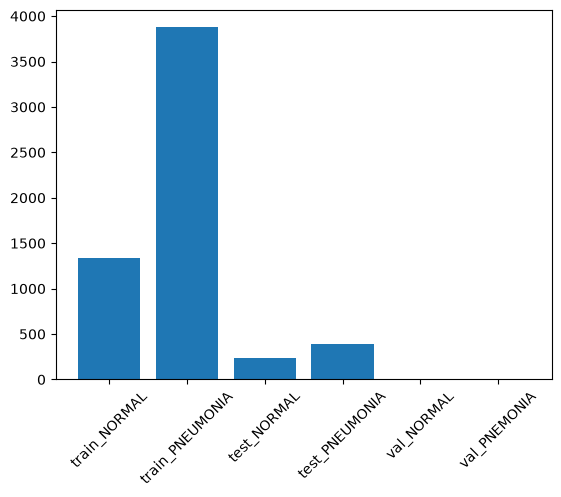

In [18]:
import matplotlib.pyplot as plt
plt.bar(labels,values)
plt.xticks(rotation= 45)
plt.show()

In [19]:
from PIL import Image

In [20]:
train_NORMAL_path = Path("./data/train/NORMAL/")

In [21]:
with Image.open( "./data/train/NORMAL/IM-0115-0001.jpeg") as img:
    width , height = img.size
    print(f"width :{width}",
    f"height :{height}")

width :2090 height :1858


In [22]:
widths = []
heights = []
for p in Path.iterdir(train_NORMAL_path):
    if p.is_file():
        with Image.open(p) as image:
            width  , height= image.size
            widths.append(width)
            heights.append(height)


In [23]:
print(len(widths))

print(len(heights))

1341
1341


In [24]:
print(f"mean:{np.mean(widths)}")
print(f"std:{np.std(widths)}")
print(f"min:{np.min(widths)}")
print(f"max:{np.max(widths)}")

mean:1667.7345264727815
std:289.10265844957775
min:912
max:2916


In [25]:
def get_data(kind,species):
    widths = []
    heights = []
    selected_path = Path(f"./data/{kind}/{species}/")
    for p in Path.iterdir(selected_path):
        if p.is_file():
            with Image.open(p) as image:
                width  , height= image.size
                widths.append(width)
                heights.append(height)
    return widths , heights

def get_statics_value(value):
    mean_value = np.mean(value)
    std_value = np.std(value)
    max_value = np.max(value)
    min_value = np.min(value)
    return dict([( "mean" ,mean_value), ( "std" ,std_value ), ( "max" ,max_value) , ("min" ,min_value)])

In [26]:
NORMAL_train_w , NORMAL_train_h = get_data("train", "NORMAL")
NORMAL_train_w_values= get_statics_value(NORMAL_train_w)
NORMAL_train_w_values

{'mean': np.float64(1667.7345264727815),
 'std': np.float64(289.10265844957775),
 'max': np.int64(2916),
 'min': np.int64(912)}

In [27]:
NORMAL_train_h_values = get_statics_value(NORMAL_train_h)
NORMAL_train_h_values

{'mean': np.float64(1381.4310216256524),
 'std': np.float64(326.19904080232703),
 'max': np.int64(2663),
 'min': np.int64(672)}

In [28]:
PNEUMONIA_train_w , PNEUMONIA_train_h = get_data("train", "PNEUMONIA")
PNEUMONIA_train_w_values= get_statics_value(PNEUMONIA_train_w)
PNEUMONIA_train_w_values

{'mean': np.float64(1200.4836129032258),
 'std': np.float64(291.26808567274077),
 'max': np.int64(2772),
 'min': np.int64(384)}

In [29]:
PNEUMONIA_train_h_values= get_statics_value(PNEUMONIA_train_h)
PNEUMONIA_train_h_values

{'mean': np.float64(825.0268387096775),
 'std': np.float64(277.0380047103235),
 'max': np.int64(2304),
 'min': np.int64(127)}

In [30]:
NORMAL_val_w , NORMAL_val_h = get_data("val", "NORMAL")
NORMAL_val_w_values = get_statics_value(NORMAL_val_w)
NORMAL_val_w_values

{'mean': np.float64(1479.5),
 'std': np.float64(207.4072081678937),
 'max': np.int64(1776),
 'min': np.int64(1240)}

In [31]:
NORMAL_val_h_values = get_statics_value(NORMAL_val_h)
NORMAL_val_h_values

{'mean': np.float64(1191.875),
 'std': np.float64(166.51909612714093),
 'max': np.int64(1416),
 'min': np.int64(928)}

In [32]:
NORMAL_test_w , NORMAL_test_h = get_data("test", "NORMAL")
NORMAL_test_w_values = get_statics_value(NORMAL_test_w)
NORMAL_test_w_values

{'mean': np.float64(1800.3034188034187),
 'std': np.float64(365.1477365060494),
 'max': np.int64(2752),
 'min': np.int64(984)}

In [33]:
NORMAL_test_h_values = get_statics_value(NORMAL_test_h)
NORMAL_test_h_values

{'mean': np.float64(1369.0897435897436),
 'std': np.float64(428.2607596673719),
 'max': np.int64(2713),
 'min': np.int64(496)}

In [34]:
PNEUMONIA_test_w , PNEUMONIA_test_h = get_data("test", "PNEUMONIA")
PNEUMONIA_test_w_values = get_statics_value(PNEUMONIA_test_w)
PNEUMONIA_test_w_values

{'mean': np.float64(1140.823076923077),
 'std': np.float64(208.59048821829802),
 'max': np.int64(2000),
 'min': np.int64(728)}

In [35]:
PNEUMONIA_test_h_values = get_statics_value(PNEUMONIA_test_h)
PNEUMONIA_test_h_values

{'mean': np.float64(765.2897435897436),
 'std': np.float64(192.84975059631904),
 'max': np.int64(1456),
 'min': np.int64(344)}

In [36]:
PNEUMONIA_val_w , PNEUMONIA_val_h = get_data("val", "PNEUMONIA")
PNEUMONIA_val_w_values = get_statics_value(PNEUMONIA_val_w)
PNEUMONIA_val_w_values

{'mean': np.float64(1217.0),
 'std': np.float64(214.82783804712088),
 'max': np.int64(1664),
 'min': np.int64(968)}

In [37]:
PNEUMONIA_val_h_values = get_statics_value(PNEUMONIA_val_h)
PNEUMONIA_val_h_values

{'mean': np.float64(814.0),
 'std': np.float64(174.71119025408763),
 'max': np.int64(1128),
 'min': np.int64(592)}

In [38]:
df = pd.DataFrame({
    "NORMAL_train_width": NORMAL_train_w_values ,
    "NORMAL_train_height" : NORMAL_train_h_values,
    "PNEUMONIA_train_width" : PNEUMONIA_train_w_values,
    "PNEUMONIA_train_height" : PNEUMONIA_train_h_values,
    "NORMAL_test_width" : NORMAL_test_w_values,
    "NORMAL_test_height" : NORMAL_test_h_values,
    "PNEUMONIA_test_width" : PNEUMONIA_test_w_values,
    "PNEUMONIA_test_height" : PNEUMONIA_test_h_values,
    "NORMAL_val_width" : NORMAL_val_w_values,
    "NORMAL_val_height" : NORMAL_val_h_values,
    "PNEUMONIA_val_width" : PNEUMONIA_val_w_values,
    "PNEUMONIA_val_height" : PNEUMONIA_val_h_values
})

In [39]:
df

,NORMAL_train_width,NORMAL_train_height,PNEUMONIA_train_width,PNEUMONIA_train_height,NORMAL_test_width,NORMAL_test_height,PNEUMONIA_test_width,PNEUMONIA_test_height,NORMAL_val_width,NORMAL_val_height,PNEUMONIA_val_width,PNEUMONIA_val_height
mean,1667.734526,1381.431022,1200.483613,825.026839,1800.303419,1369.089744,1140.823077,765.289744,1479.500000,1191.875000,1217.000000,814.00000
std,289.102658,326.199041,291.268086,277.038005,365.147737,428.260760,208.590488,192.849751,207.407208,166.519096,214.827838,174.71119
max,2916.000000,2663.000000,2772.000000,2304.000000,2752.000000,2713.000000,2000.000000,1456.000000,1776.000000,1416.000000,1664.000000,1128.00000
min,912.000000,672.000000,384.000000,127.000000,984.000000,496.000000,728.000000,344.000000,1240.000000,928.000000,968.000000,592.00000


画面さいずは十分バラついていると見られる。
各画像によってばらつき度合いが変わるので、画像のサイズを統一する必要がありそう。

Image.siz   

In [40]:
from PIL import ImageStat

def is_grayscale(fn):
	im = Image.open(fn).convert("RGB")
	stat = ImageStat.Stat(im)

	if abs(sum(stat.sum)/3 - stat.sum[0]) < (stat.sum[0] * 0.001) :
		return True #yes, grayscale
	else:
		return False #no,  colorimg


is_grayscale("./data/train/NORMAL/IM-0115-0001.jpeg")

True

In [41]:
def count_grayscale(kind,species):
    count=0
    selected_path = Path(f"./data/{kind}/{species}/")
    for p in Path.iterdir(selected_path):
        if p.is_file():
            if is_grayscale(p) == True:
                count +=1
    return count

In [42]:
NORMAL_train_grayscale= count_grayscale("train", "NORMAL")
NORMAL_train_grayscale

1341

In [43]:
PNEUMONIA_train_grayscale= count_grayscale("train", "PNEUMONIA")

In [44]:
PNEUMONIA_train_grayscale

3875

In [45]:
NORMAL_test_grayscale= count_grayscale("test", "NORMAL")
PNEUMONIA_test_grayscale= count_grayscale("test", "PNEUMONIA")

In [46]:
NORMAL_test_grayscale

234

In [47]:
PNEUMONIA_test_grayscale

390

In [48]:
NORMAL_val_grayscale= count_grayscale("val", "NORMAL")

In [49]:
PNEUMONIA_val_grayscale= count_grayscale("val", "PNEUMONIA")

In [50]:
PNEUMONIA_val_grayscale

8

In [51]:
NORMAL_val_grayscale

8

全画像がグレースケールと一致する。

In [52]:
img = Image.open("./data/train/NORMAL/IM-0115-0001.jpeg")

hist = img.histogram()
print(len(hist))

256


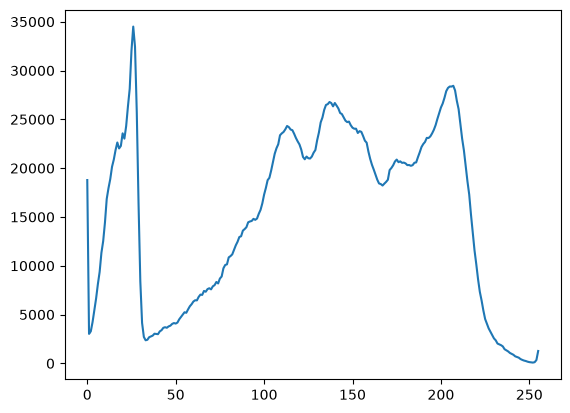

In [53]:
plt.plot(hist)

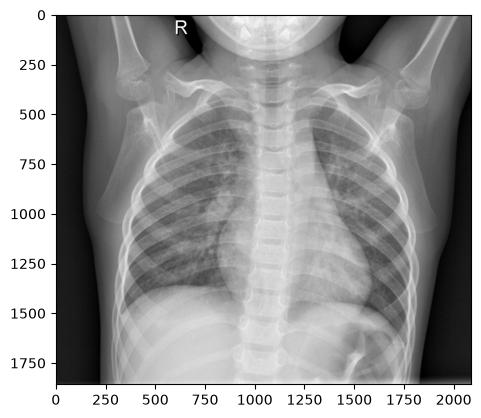

In [54]:
#　訓練用画像の確認
plt.imshow(img,cmap="gray")
plt.show()

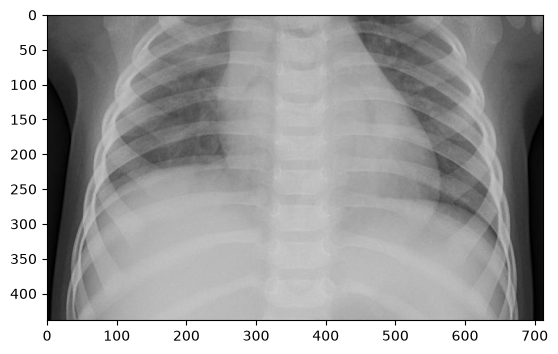

In [55]:
#　テスト用画像の確認
image =Image.open("./data/train/PNEUMONIA/person1_bacteria_1.jpeg")
plt.imshow(image)
plt.show()

In [56]:
def get_piksel(kind,species):
    images = []
    selected_path = Path(f"./data/{kind}/{species}/")
    for p in Path.iterdir(selected_path):
        if p.is_file():
            with Image.open(p) as image:
                image = image.convert("L")
                images.append(image.histogram())
    images = np.asarray(images)
    sum_images = np.sum(images,axis=0)
    mean_images = np.mean(images,axis=0)
    return sum_images ,mean_images

In [57]:
NORMAL_sum_image , NORMAL_mean_image = get_piksel("train" , "NORMAL")

In [58]:
NORMAL_sum_image , NORMAL_mean_image

(array([252899899,   5614167,   3902937,   3721520,   3788648,   3980128,
          4204126,   4362901,   4538699,   4572829,   4471988,   4454904,
          4470904,   4493338,   4475553,   4413839,   4343038,   4299703,
          4267298,   4238483,   4207109,   4191076,   4198282,   4231688,
          4279815,   4324023,   4381947,   4439077,   4524655,   4569591,
          4638100,   4740500,   4813586,   4910813,   5001960,   5087982,
          5167011,   5265512,   5363989,   5480368,   5594843,   5732097,
          5874223,   6037197,   6182054,   6315948,   6466962,   6601411,
          6750580,   6910723,   7065029,   7240736,   7412563,   7592848,
          7766723,   7939107,   8111163,   8285749,   8471487,   8647539,
          8833373,   9023837,   9206870,   9401640,   9585225,   9774210,
          9974236,  10166842,  10368245,  10566359,  10752483,  10936796,
         11130137,  11310159,  11491139,  11668738,  11856730,  12049247,
         12227152,  12403917,  1258689

In [59]:
PNEUMONIA_sum_image , PNEUMONIA_mean_image = get_piksel("train" , "PNEUMONIA")
PNEUMONIA_sum_image , PNEUMONIA_mean_image

(array([178569087,  13988933,  10391909,   8817335,   8675862,   8923483,
          9317886,   9425867,   9279100,   9448398,   9494292,   9563417,
          9365027,   9497330,   9304279,   9422410,   9554367,   9705340,
          9647620,   9653182,   9584704,   9530914,   9426997,   9258256,
          9036320,   8838415,   8667545,   8401991,   8138407,   8045257,
          7961908,   7889396,   7778725,   7732040,   7716017,   7754756,
          7766138,   7809654,   7893669,   8062797,   8238207,   8344086,
          8515859,   8703555,   8909178,   9129143,   9340443,   9627948,
          9912567,  10168741,  10424312,  10721912,  10980206,  11238005,
         11488776,  11727617,  11945932,  12162138,  12342623,  12496348,
         12659771,  12792187,  12913200,  13011828,  13103444,  13158437,
         13254381,  13339429,  13435757,  13509865,  13573820,  13634424,
         13700704,  13769250,  13835368,  13911673,  13991725,  14086062,
         14173047,  14284092,  1438281

In [60]:
# グレースケールだが、RGBのものがあるかどうかの確認用関数
def check_length_scale(kind,species):
    count = 0
    selected_path = Path(f"./data/{kind}/{species}/")
    for p in Path.iterdir(selected_path):
        if p.is_file():
            with Image.open(p) as image:
                hist =image.histogram()
                if len(hist) == 768 :
                    count += 1
    return count
check_length_scale("train" ,"PNEUMONIA")

283

全部グレースケール画像であったが、一部RGB形式で保存されていた。

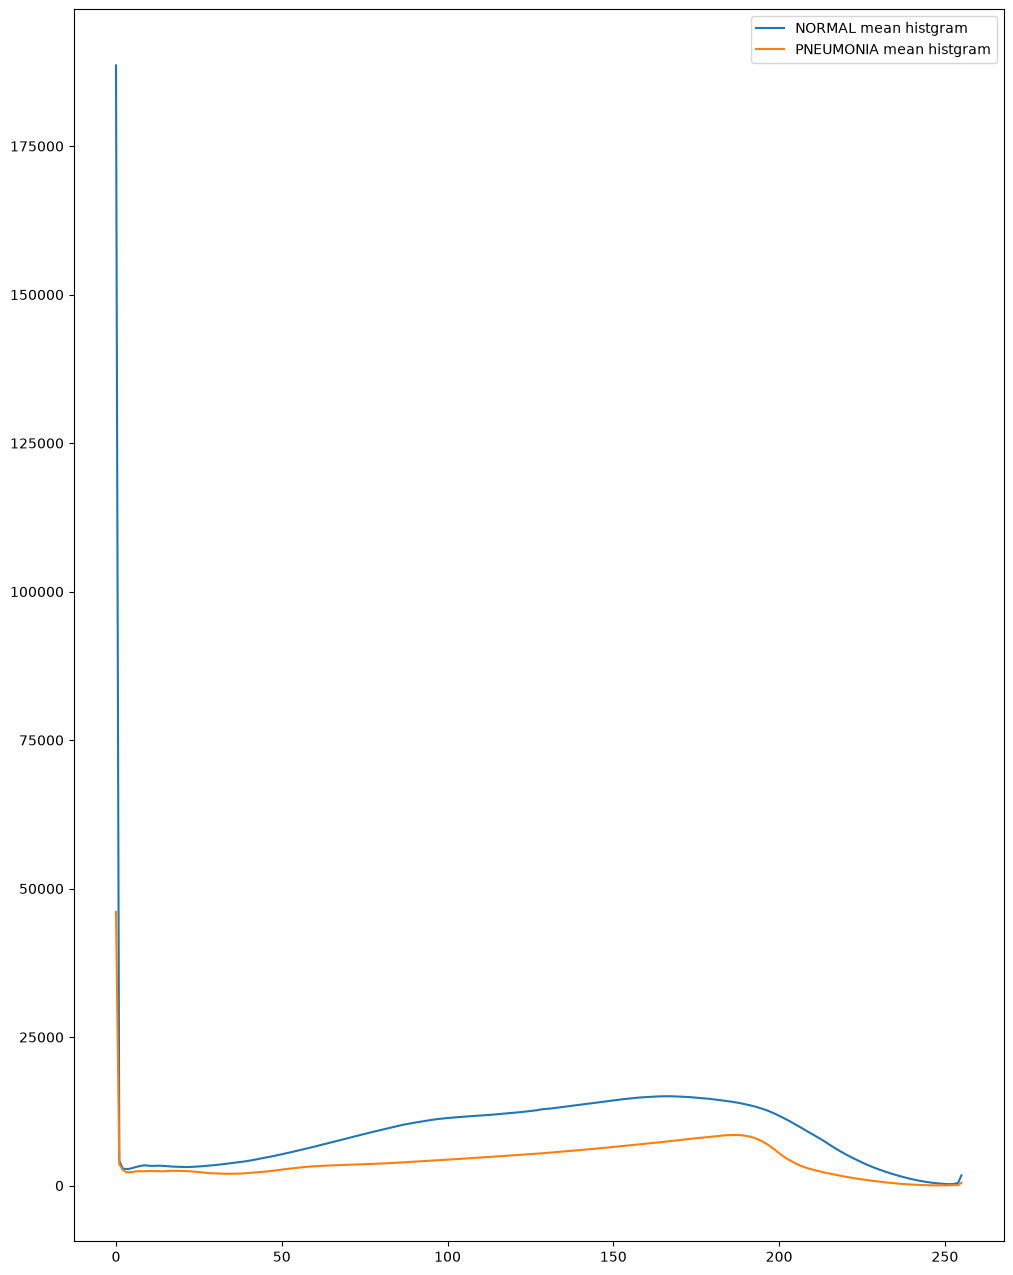

In [61]:
fig ,ax = plt.subplots(figsize=(12,16))

ax.plot(NORMAL_mean_image, label = "NORMAL mean histgram")
ax.plot(PNEUMONIA_mean_image,label = "PNEUMONIA mean histgram")
ax.legend()
plt.show()

PNEUMONIAとNORMALの大きな違いは、0~25の間NORMAL の方が数値は高くなっている。
もう一点は、50付近から200付近まで差が大きいことがわかる。

In [62]:
def check_broken_file(kind , species):
    count = 0
    selected_path = Path(f"./data/{kind}/{species}/")
    for p in Path.iterdir(selected_path):
        if p.is_file():
            image =Image.open(p)
            try:
                pixels = image.load()
            except:
                count += 1

    return print(f"{kind}/{species}の破損ファイルは{count}個です。")

In [63]:
check_broken_file("train" , "PNEUMONIA")

train/PNEUMONIAの破損ファイルは0個です。


In [64]:
check_broken_file("train" , "NORMAL")

train/NORMALの破損ファイルは0個です。


In [65]:
check_broken_file("test" , "NORMAL")

test/NORMALの破損ファイルは0個です。


In [66]:
check_broken_file("test" , "PNEUMONIA")

test/PNEUMONIAの破損ファイルは0個です。


In [67]:
check_broken_file("val" , "PNEUMONIA")

val/PNEUMONIAの破損ファイルは0個です。


In [68]:
check_broken_file("val" , "NORMAL")

val/NORMALの破損ファイルは0個です。


読み込み失敗による破損ファイルの数は0個であった。

In [69]:
# PNEUMONIA train の高さ127の画像を確認する
def get_min_height():
    path_list = []
    path = Path("./data/train/PNEUMONIA/")
    for p in Path.iterdir(path):
        if p.is_file():
            with Image.open(p) as image:
                widrh , height = image.size
                if height == 127:
                    print(p)
    return None

In [70]:
path = get_min_height()

data/train/PNEUMONIA/person407_virus_811.jpeg


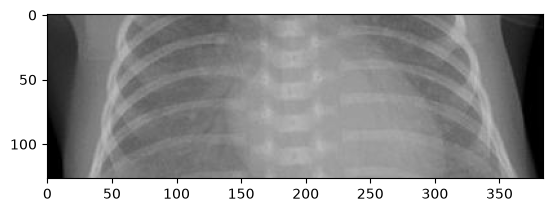

In [71]:
image = Image.open("data/train/PNEUMONIA/person407_virus_811.jpeg")
plt.imshow(image,cmap= "gray")
plt.show()

縦横比が極端で、全体の画像が見えにく画像になっている。

### STEP2 Augmentation

In [72]:
import torchvision.transforms as transforms

In [73]:
#train全体の平均と標準偏差を求める
# a :頻度　 b : 値
b =np.arange(256)

a = NORMAL_sum_image  +PNEUMONIA_sum_image

In [74]:
add_mean= np.sum(a *b) / np.sum(a)

In [75]:
add_mean

np.float64(124.30439268529355)

In [76]:
add_var= np.sum((b  - add_mean)**2 * a ) / np.sum(a)

In [77]:
add_std =add_var **(0.5)

In [78]:
add_std

np.float64(62.62273995946972)

In [79]:
norm_mean = add_mean / 255
norm_std = add_std / 255

In [80]:
transfromers = transforms.Compose([transforms.Resize((224,224)), transforms.ToTensor(),transforms.Normalize((norm_mean ,norm_mean,norm_mean), (norm_std,norm_std,norm_std))])

In [81]:
def Make_Pipeline_data(kind,species):
    image_list = []
    selected_path = Path(f"./data/{kind}/{species}/")
    for p in Path.iterdir(selected_path):
        if p.is_file():
            image = Image.open(p).convert("RGB")
            image_resized = transfromers(image)
            image_list.append(image_resized)
    return image_list


In [82]:
val_NORMAL_list = Make_Pipeline_data("val", "NORMAL")

In [83]:
val_PNEUMONIA_list = Make_Pipeline_data("val", "PNEUMONIA")

In [84]:
test_NORMAL_list = Make_Pipeline_data("test", "NORMAL")

In [85]:
test_PNEUMONIA_list = Make_Pipeline_data("test", "PNEUMONIA")

In [86]:
print(len(val_NORMAL_list))

8


In [87]:
print(len(val_PNEUMONIA_list))

8


In [88]:
print((val_NORMAL_list[0].shape))

torch.Size([3, 224, 224])


In [89]:
print(len(test_NORMAL_list))


234


In [90]:
print(len(test_PNEUMONIA_list))

390


In [91]:
print(test_PNEUMONIA_list[0].shape)

torch.Size([3, 224, 224])


In [92]:
print(test_NORMAL_list[0].shape)

torch.Size([3, 224, 224])


In [93]:
# 左右反転あり
train_transfromers_rotation = transforms.Compose([transforms.Resize((224,224)),
transforms.RandomAffine(degrees=10, translate=(0.1, 0.1), scale=(0.9, 1.1)),transforms.RandomHorizontalFlip(p=0.5), 
transforms.ColorJitter(brightness=0.1, contrast=0.1),
transforms.ToTensor(),transforms.Normalize((norm_mean ,norm_mean,norm_mean), (norm_std,norm_std,norm_std))])

# 左右反転なし
train_transfromers  = transforms.Compose([transforms.Resize((224,224)),transforms.RandomAffine(degrees=10, 
translate=(0.1, 0.1), scale=(0.9, 1.1)),transforms.ColorJitter(brightness=0.1, contrast=0.1),
 transforms.ToTensor(),transforms.Normalize((norm_mean ,norm_mean,norm_mean), (norm_std,norm_std,norm_std))])

In [94]:
def Make_Pipeline_train_data(kind,species,select_transforms):
    image_list = []
    selected_path = Path(f"./data/{kind}/{species}/")
    for p in Path.iterdir(selected_path):
        if p.is_file():
            image = Image.open(p).convert("RGB")
            image_resized = select_transforms(image)
            image_list.append(image_resized)
    return image_list

In [95]:
train_NORMAL_list= Make_Pipeline_train_data("train" , "NORMAL",train_transfromers)

In [96]:
train_NORMAL_list

[tensor([[[-1.9371, -1.9371, -1.9371,  ..., -1.9371, -1.9371, -1.9371],
          [-1.9371, -1.9371, -1.9371,  ..., -1.9371, -1.9371, -1.9371],
          [-1.9371, -1.9371, -1.9371,  ..., -1.9371, -1.9371, -1.9371],
          ...,
          [-1.9371, -1.9371, -1.9371,  ..., -1.9371, -1.9371, -1.9371],
          [-1.9371, -1.9371, -1.9371,  ..., -1.9371, -1.9371, -1.9371],
          [-1.9371, -1.9371, -1.9371,  ..., -1.9371, -1.9371, -1.9371]],
 
         [[-1.9371, -1.9371, -1.9371,  ..., -1.9371, -1.9371, -1.9371],
          [-1.9371, -1.9371, -1.9371,  ..., -1.9371, -1.9371, -1.9371],
          [-1.9371, -1.9371, -1.9371,  ..., -1.9371, -1.9371, -1.9371],
          ...,
          [-1.9371, -1.9371, -1.9371,  ..., -1.9371, -1.9371, -1.9371],
          [-1.9371, -1.9371, -1.9371,  ..., -1.9371, -1.9371, -1.9371],
          [-1.9371, -1.9371, -1.9371,  ..., -1.9371, -1.9371, -1.9371]],
 
         [[-1.9371, -1.9371, -1.9371,  ..., -1.9371, -1.9371, -1.9371],
          [-1.9371, -1.9371,

In [97]:
train_PNEUMONIA_list= Make_Pipeline_train_data("train" , "PNEUMONIA",train_transfromers)

In [98]:
print(len(train_NORMAL_list))

1341


In [99]:
print(len(train_PNEUMONIA_list))

3875


In [100]:
print(train_NORMAL_list[0].shape)

torch.Size([3, 224, 224])


In [101]:
print(train_PNEUMONIA_list[0].shape)

torch.Size([3, 224, 224])


## 3 モデル実装

In [102]:
def Make_dataset(kind):
    path_NORMAL_list = []
    path_PNEUMONIA_list =[]
    species = "NORMAL"
    labels = 0
    selected_path = Path(f"./data/{kind}/{species}/")
    for p in Path.iterdir(selected_path):
        if p.is_file():
            path_NORMAL_list.append(p)
            df_NORMAL = pd.DataFrame({
                "label": labels , 
                "path" : path_NORMAL_list,
            })
    species = "PNEUMONIA"  
    labels = 1
    selected_path = Path(f"./data/{kind}/{species}/")
    for p in Path.iterdir(selected_path):
        if p.is_file():
            path_PNEUMONIA_list.append(p)
            df_PNEUMONIA = pd.DataFrame({
                "label": labels,
                "path" : path_PNEUMONIA_list
            })
    df = pd.concat([df_NORMAL,df_PNEUMONIA])
    return df

In [103]:
df = Make_dataset("train")

In [104]:
df

,label,path
0,0,data/train/NORMAL/NORMAL2-IM-0927-0001.jpeg
1,0,data/train/NORMAL/NORMAL2-IM-1056-0001.jpeg
2,0,data/train/NORMAL/IM-0427-0001.jpeg
3,0,data/train/NORMAL/NORMAL2-IM-1260-0001.jpeg
4,0,data/train/NORMAL/IM-0656-0001-0001.jpeg
...,...,...
3870,1,data/train/PNEUMONIA/person142_virus_288.jpeg
3871,1,data/train/PNEUMONIA/person364_bacteria_1659.jpeg
3872,1,data/train/PNEUMONIA/person1323_virus_2283.jpeg
3873,1,data/train/PNEUMONIA/person772_virus_1401.jpeg


In [105]:
len(df)

5216

In [106]:
df["label"].value_counts()

label
1    3875
0    1341
Name: count, dtype: int64

In [107]:
from torch.utils.data import Dataset

In [108]:
def Make_dataset(kind):
    path_NORMAL_list = []
    path_PNEUMONIA_list =[]
    species = "NORMAL"
    labels = 0
    selected_path = Path(f"./data/{kind}/{species}/")
    for p in Path.iterdir(selected_path):
        if p.is_file():
            path_NORMAL_list.append(p)
            df_NORMAL = pd.DataFrame({
                "label": labels , 
                "path" : path_NORMAL_list,
            })
    species = "PNEUMONIA"  
    labels = 1
    selected_path = Path(f"./data/{kind}/{species}/")
    for p in Path.iterdir(selected_path):
        if p.is_file():
            path_PNEUMONIA_list.append(p)
            df_PNEUMONIA = pd.DataFrame({
                "label": labels,
                "path" : path_PNEUMONIA_list
            })
    df = pd.concat([df_NORMAL,df_PNEUMONIA])
    return df

In [109]:
class My_Dataset(Dataset):

    def __init__(self,df,transforms):
        super().__init__()
        self.df = df
        self.transforms = transforms
    def __len__(self):
        return len(self.df)
    def __getitem__(self, idx):
        label ,path_list   = self.df.iloc[idx]
        image = Image.open(path_list).convert("RGB")
        resize = self.transforms(image)
        return  resize , label

In [110]:
test  = My_Dataset(df,train_transfromers)
print(len(test))
print(test[0][1])
test[0][0].shape

5216
0


torch.Size([3, 224, 224])

In [111]:
train_df = Make_dataset("train")

In [112]:
test_df =Make_dataset("test")

In [113]:
val_df = Make_dataset("val")

In [114]:
print(len(train_df))

5216


In [115]:
print(len(test_df))

624


In [116]:
print(len(val_df))

16


In [117]:
train_datasets = My_Dataset(train_df,train_transfromers)

In [118]:
test_datasets = My_Dataset(test_df, transfromers )

In [119]:
val_datasets = My_Dataset(val_df,transfromers )

In [120]:
print(len(train_datasets))

train_datasets[0][0]

5216


tensor([[[-1.9850, -1.9850, -1.9850,  ..., -1.9850, -1.9850, -1.9850],
         [-1.9850, -1.9850, -1.9850,  ..., -1.9850, -1.9850, -1.9850],
         [-1.9850, -1.9850, -1.9850,  ..., -1.9850, -1.9850, -1.9850],
         ...,
         [-1.8732, -1.8732, -1.8892,  ..., -1.9850, -1.9850, -1.9371],
         [-1.8732, -1.9211, -1.9530,  ..., -1.9690, -1.9690, -1.9211],
         [-1.8732, -1.9211, -1.9371,  ..., -1.9690, -1.9211, -1.8732]],

        [[-1.9850, -1.9850, -1.9850,  ..., -1.9850, -1.9850, -1.9850],
         [-1.9850, -1.9850, -1.9850,  ..., -1.9850, -1.9850, -1.9850],
         [-1.9850, -1.9850, -1.9850,  ..., -1.9850, -1.9850, -1.9850],
         ...,
         [-1.8732, -1.8732, -1.8892,  ..., -1.9850, -1.9850, -1.9371],
         [-1.8732, -1.9211, -1.9530,  ..., -1.9690, -1.9690, -1.9211],
         [-1.8732, -1.9211, -1.9371,  ..., -1.9690, -1.9211, -1.8732]],

        [[-1.9850, -1.9850, -1.9850,  ..., -1.9850, -1.9850, -1.9850],
         [-1.9850, -1.9850, -1.9850,  ..., -1

In [121]:
print(len(test_datasets))

test_datasets[0][0]

624


tensor([[[-1.6496, -1.6337, -1.6337,  ..., -0.9310, -0.6915, -0.3562],
         [-1.6656, -1.6337, -1.6337,  ..., -0.9310, -0.6915, -0.3562],
         [-1.6496, -1.6496, -1.6496,  ..., -0.9470, -0.6915, -0.3562],
         ...,
         [-1.6975, -1.6816, -1.6816,  ..., -1.3941, -1.2983, -1.2504],
         [-1.6816, -1.6656, -1.6816,  ..., -1.3941, -1.3143, -1.2504],
         [-1.6975, -1.6656, -1.6656,  ..., -1.3941, -1.3143, -1.2344]],

        [[-1.6496, -1.6337, -1.6337,  ..., -0.9310, -0.6915, -0.3562],
         [-1.6656, -1.6337, -1.6337,  ..., -0.9310, -0.6915, -0.3562],
         [-1.6496, -1.6496, -1.6496,  ..., -0.9470, -0.6915, -0.3562],
         ...,
         [-1.6975, -1.6816, -1.6816,  ..., -1.3941, -1.2983, -1.2504],
         [-1.6816, -1.6656, -1.6816,  ..., -1.3941, -1.3143, -1.2504],
         [-1.6975, -1.6656, -1.6656,  ..., -1.3941, -1.3143, -1.2344]],

        [[-1.6496, -1.6337, -1.6337,  ..., -0.9310, -0.6915, -0.3562],
         [-1.6656, -1.6337, -1.6337,  ..., -0

In [122]:
print(len(val_datasets))

val_datasets[0][0]

16


tensor([[[-1.8572, -1.7454, -1.5858,  ..., -0.9310, -1.0109, -1.0428],
         [-1.8413, -1.7454, -1.5219,  ..., -0.8831, -0.9151, -1.0109],
         [-1.8413, -1.7454, -1.4740,  ..., -0.8352, -0.8991, -1.0428],
         ...,
         [-1.9850, -1.9850, -1.9850,  ..., -1.9850, -1.9850, -1.9850],
         [-1.9850, -1.9850, -1.9850,  ..., -1.9850, -1.9850, -1.9850],
         [-1.9850, -1.9850, -1.9850,  ..., -1.9850, -1.9850, -1.9850]],

        [[-1.8572, -1.7454, -1.5858,  ..., -0.9310, -1.0109, -1.0428],
         [-1.8413, -1.7454, -1.5219,  ..., -0.8831, -0.9151, -1.0109],
         [-1.8413, -1.7454, -1.4740,  ..., -0.8352, -0.8991, -1.0428],
         ...,
         [-1.9850, -1.9850, -1.9850,  ..., -1.9850, -1.9850, -1.9850],
         [-1.9850, -1.9850, -1.9850,  ..., -1.9850, -1.9850, -1.9850],
         [-1.9850, -1.9850, -1.9850,  ..., -1.9850, -1.9850, -1.9850]],

        [[-1.8572, -1.7454, -1.5858,  ..., -0.9310, -1.0109, -1.0428],
         [-1.8413, -1.7454, -1.5219,  ..., -0

In [123]:
from torch.utils.data import DataLoader

In [124]:
train_data = DataLoader(train_datasets,16, shuffle=True)
test_data = DataLoader(test_datasets,16,shuffle=False)
val_data = DataLoader(val_datasets , 16 ,shuffle= False)


In [125]:
for images, labels in train_data:
    print(images.shape)
    print(labels.shape)
    break

torch.Size([16, 3, 224, 224])
torch.Size([16])


In [126]:
import torch.nn as nn 

In [127]:
class BaselineCNN(nn.Module):
    def __init__(self, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.Conv2d = nn.Conv2d(in_channels=3,out_channels=2,kernel_size=3, padding=1)
        self.Relu = nn.ReLU()
        self.MaxPool2d = nn.MaxPool2d(kernel_size=3)
        self.Linear = nn.Linear(in_features=10952 , out_features=2)
        self.flatten = nn.Flatten()
    def forward(self,x):
        x = self.Conv2d(x)
        x = self.Relu(x)
        x = self.MaxPool2d(x)
        x = self.flatten(x)
        x = self.Linear(x)
        return x

In [128]:
model = BaselineCNN()
dummy = torch.randn(1, 3, 224, 224)
x = model.Conv2d(dummy)
print(x.shape)
x = model.MaxPool2d(x)
x = model.flatten(x)
x = model.Linear(x)
print(x.shape)

torch.Size([1, 2, 224, 224])
torch.Size([1, 2])


In [129]:
test = BaselineCNN()
test(dummy)

tensor([[-0.0757,  0.2255]], grad_fn=<AddmmBackward0>)

In [130]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [131]:
def calc_train(model,dataset,epoch_num=3):
    mean_list = []
    for epoch in range(epoch_num):
        loss_list= []
        for images , labels in dataset :
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs ,labels)
            loss.backward()
            optimizer.step()
            loss_value = loss.item()
            loss_list.append(loss_value)
        mean_loss = np.mean(loss_list)
        mean_list.append(mean_loss)
        print(f"epoch {epoch}: mean_loss = {mean_loss}")

In [132]:
calc_train(model,train_data,epoch_num=10)

epoch 0: mean_loss = 0.3539497102010835
epoch 1: mean_loss = 0.27175869914400247
epoch 2: mean_loss = 0.24129044715932177
epoch 3: mean_loss = 0.2525895528175348
epoch 4: mean_loss = 0.24666404097335287
epoch 5: mean_loss = 0.2145447672567576
epoch 6: mean_loss = 0.21480007653633143
epoch 7: mean_loss = 0.21443363216254244
epoch 8: mean_loss = 0.21772657513998425
epoch 9: mean_loss = 0.22879123525476894


In [133]:
def calc_test(model,dataset,epoch_num=3):
    mean_list = []
    TP = FP = FN = TN =0
    mat_list = []
    for epoch in range(epoch_num):
        loss_list= []
        for images , labels in dataset :
            outputs = model(images)
            pred_label = torch.argmax(outputs, dim=1)
            loss = criterion(outputs ,labels)
            loss_value = loss.item()
            loss_list.append(loss_value)
            TP += ((pred_label == 1) & (labels == 1)).sum().item()
            FP += ((pred_label == 1) & (labels == 0)).sum().item()
            FN += ((pred_label == 0) & (labels == 1)).sum().item()
            TN += ((pred_label == 0) & (labels == 0)).sum().item()
        if epoch ==0 :    
            mat_list.append((TP,TN,FN,FP))
            conf_mat = np.array(mat_list)
            print(conf_mat)
        mean_loss = np.mean(loss_list)
        mean_list.append(mean_loss)
        print(f"epoch {epoch}: mean_loss = {mean_loss}")
    accuracy = (TP + TN) / (TP +FP + FN +TN)
    precision = TP /(TP +FP) 
    recall = TP /(TP +FN)
    F1 = 2 * precision *recall /(recall +precision)
    return accuracy ,precision , recall ,F1

In [134]:
test_accuracy , test_prescision, test_recall ,test_F1 =calc_test(model,test_data,epoch_num=1)

[[378 146  12  88]]
epoch 0: mean_loss = 0.37504590125993276


In [ ]:
print(f"acc : {test_accuracy}", 
      f"prcision: {test_prescision}",
      f"recall :{test_recall} ",
      f"F1 : {test_F1}")

In [ ]:
OUTPUTS_DIR = Path("..")/ "outputs" / "models"
OUTPUTS_DIR.mkdir(parents=True, exist_ok=True)
save_path = OUTPUTS_DIR / "ResNet18.pth"
torch.save(model.state_dict(), save_path)

In [135]:
print(f"accuracy{test_accuracy}")

print(f"precision:{test_prescision}")

print(f"recall:{test_recall}")

print(f"F1 :{test_F1}")

accuracy0.8397435897435898
precision:0.8111587982832618
recall:0.9692307692307692
F1 :0.883177570093458


In [136]:
val_accuracy , val_prescision, val_recall ,val_F1 =calc_test(model,val_data,epoch_num=1)

[[8 3 0 5]]
epoch 0: mean_loss = 0.5397061705589294


In [137]:
print(f"accuracy{val_accuracy}")

print(f"precision:{val_prescision}")

print(f"recall:{val_recall}")

print(f"F1 :{val_F1}")

accuracy0.6875
precision:0.6153846153846154
recall:1.0
F1 :0.761904761904762


In [138]:
def calc_test_false_detecit(model,dataset,epoch_num=1):
    mean_list = []
    TP = FP = FN = TN =0
    mat_list = []
    false_detect = []
    for epoch in range(epoch_num):
        loss_list= []
        for i , (images , labels) in enumerate(dataset):
            outputs = model(images)
            pred_label = torch.argmax(outputs, dim=1)
            local_idx = torch.where((pred_label == 1) & (labels == 0))[0]
            global_idx = i * 16  + local_idx            
            loss = criterion(outputs ,labels)
            loss_value = loss.item()
            loss_list.append(loss_value)
            TP += ((pred_label == 1) & (labels == 1)).sum().item()
            FP += ((pred_label == 1) & (labels == 0)).sum().item()
            FN += ((pred_label == 0) & (labels == 1)).sum().item()
            TN += ((pred_label == 0) & (labels == 0)).sum().item()
            false_detect.append(global_idx)
        if epoch ==0 :    
            mat_list.append((TP,TN,FN,FP))
            conf_mat = np.array(mat_list)
            print(conf_mat)
        mean_loss = np.mean(loss_list)
        mean_list.append(mean_loss)
        print(f"epoch {epoch}: mean_loss = {mean_loss}")
    accuracy = (TP + TN) / (TP +FP + FN +TN)
    precision = TP /(TP +FP) 
    recall = TP /(TP +FN)
    F1 = 2 * precision *recall /(recall +precision)
    return accuracy ,precision , recall ,F1 ,false_detect

In [139]:
val_accuracy , val_prescision, val_recall ,val_F1 ,false_val =calc_test_false_detecit(model,val_data,epoch_num=1)

[[8 3 0 5]]
epoch 0: mean_loss = 0.5397061705589294


In [140]:
print(false_val)

[tensor([0, 1, 3, 4, 7])]


In [141]:
test_accuracy , test_prescision, test_recall ,test_F1 , test_false_detict =calc_test_false_detecit(model,test_data,epoch_num=1)

[[378 146  12  88]]
epoch 0: mean_loss = 0.37504590125993276


In [142]:
print(test_accuracy)

0.8397435897435898


In [143]:
print(test_false_detict)

[tensor([ 2,  3,  4,  5,  6,  8,  9, 14]), tensor([17, 24, 25, 26, 27]), tensor([32, 45, 47]), tensor([48, 52, 53, 61, 63]), tensor([65, 67, 71, 72, 76, 79]), tensor([80, 82, 84, 94, 95]), tensor([102, 104, 106, 108, 110]), tensor([114, 117, 121, 124, 125, 126]), tensor([128, 132, 134, 136, 139]), tensor([146, 148, 151, 152, 155, 156, 157]), tensor([160, 161, 163, 171, 172, 175]), tensor([176, 179, 181, 183, 186, 188, 190]), tensor([192, 193, 194, 195, 199, 200, 201, 204, 206]), tensor([208, 209, 210, 212, 215]), tensor([225, 226, 230, 231, 232, 233]), tensor([], dtype=torch.int64), tensor([], dtype=torch.int64), tensor([], dtype=torch.int64), tensor([], dtype=torch.int64), tensor([], dtype=torch.int64), tensor([], dtype=torch.int64), tensor([], dtype=torch.int64), tensor([], dtype=torch.int64), tensor([], dtype=torch.int64), tensor([], dtype=torch.int64), tensor([], dtype=torch.int64), tensor([], dtype=torch.int64), tensor([], dtype=torch.int64), tensor([], dtype=torch.int64), tensor(

In [144]:
test_tensor = torch.cat(test_false_detict)

In [145]:
test_tensor
len(test_tensor)

88

In [146]:
val_tensor = torch.cat(false_val)

In [147]:
val_tensor
len(val_tensor)

5

In [148]:
test_tensor[0]

tensor(2)

In [149]:
test_index =test_tensor.tolist()
path_test=test_df.iloc[test_index]["path"]

In [150]:
val_index = val_tensor.tolist()
path_val = val_df.iloc[val_index]["path"]

In [151]:
print(path_test)

2           data/test/NORMAL/NORMAL2-IM-0272-0001.jpeg
3           data/test/NORMAL/NORMAL2-IM-0102-0001.jpeg
4           data/test/NORMAL/NORMAL2-IM-0229-0001.jpeg
5           data/test/NORMAL/NORMAL2-IM-0315-0001.jpeg
6           data/test/NORMAL/NORMAL2-IM-0123-0001.jpeg
                            ...                       
226         data/test/NORMAL/NORMAL2-IM-0145-0001.jpeg
230    data/test/NORMAL/NORMAL2-IM-0246-0001-0001.jpeg
231         data/test/NORMAL/NORMAL2-IM-0292-0001.jpeg
232         data/test/NORMAL/NORMAL2-IM-0221-0001.jpeg
233         data/test/NORMAL/NORMAL2-IM-0198-0001.jpeg
Name: path, Length: 88, dtype: object


In [152]:
print(path_val)

0    data/val/NORMAL/NORMAL2-IM-1440-0001.jpeg
1    data/val/NORMAL/NORMAL2-IM-1437-0001.jpeg
3    data/val/NORMAL/NORMAL2-IM-1436-0001.jpeg
4    data/val/NORMAL/NORMAL2-IM-1430-0001.jpeg
7    data/val/NORMAL/NORMAL2-IM-1427-0001.jpeg
Name: path, dtype: object


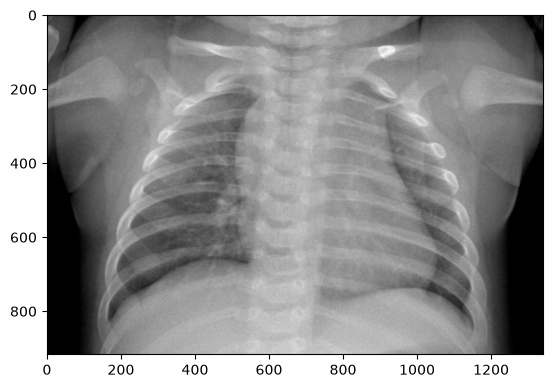

In [153]:
path = path_test.iloc[0]
img=Image.open(path)
plt.imshow(img ,cmap="gray")


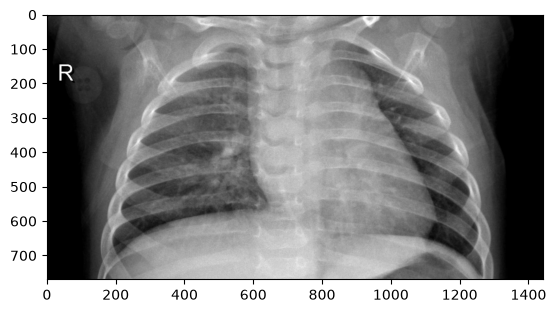

In [154]:
path = path_test.iloc[3]
img=Image.open(path)
plt.imshow(img ,cmap="gray")

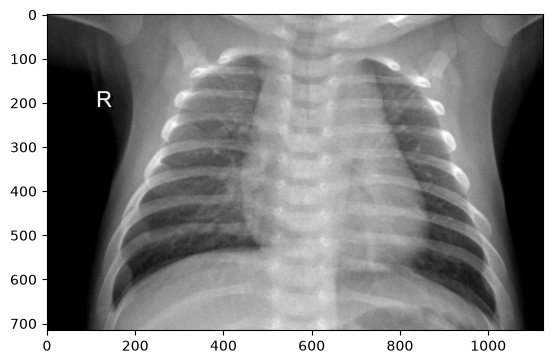

In [155]:
path = path_test.iloc[10]
img=Image.open(path)
plt.imshow(img ,cmap="gray")

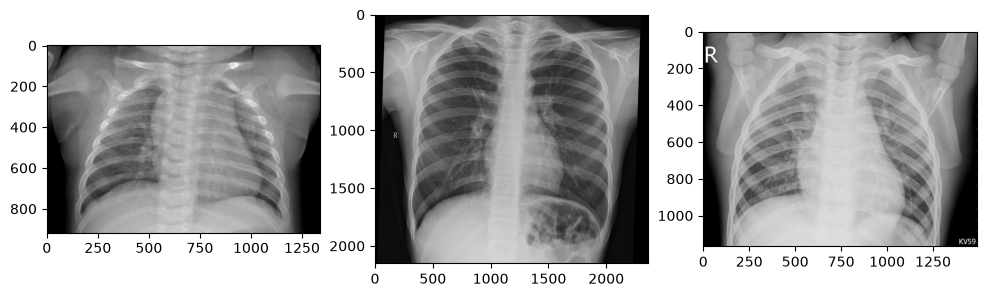

In [156]:
fig ,ax = plt.subplots(1,3,figsize=(12,12))
path = path_test.iloc[0]
img=Image.open(path)
ax[0].imshow(img ,cmap="gray")

path = path_test.iloc[1]
img=Image.open(path)
ax[1].imshow(img ,cmap="gray")

path = path_test.iloc[2]
img=Image.open(path)
ax[2].imshow(img ,cmap="gray")


plt.show()

In [157]:
## FNの誤分類を確認する
def calc_test_false_detecit2(model,dataset,epoch_num=1):
    mean_list = []
    TP = FP = FN = TN =0
    mat_list = []
    false_detect = []
    for epoch in range(epoch_num):
        loss_list= []
        for i , (images , labels) in enumerate(dataset):
            outputs = model(images)
            pred_label = torch.argmax(outputs, dim=1)
            local_idx = torch.where((pred_label == 0) & (labels == 1))[0]
            global_idx = i * 16  + local_idx            
            loss = criterion(outputs ,labels)
            loss_value = loss.item()
            loss_list.append(loss_value)
            TP += ((pred_label == 1) & (labels == 1)).sum().item()
            FP += ((pred_label == 1) & (labels == 0)).sum().item()
            FN += ((pred_label == 0) & (labels == 1)).sum().item()
            TN += ((pred_label == 0) & (labels == 0)).sum().item()
            false_detect.append(global_idx)
        if epoch ==0 :    
            mat_list.append((TP,TN,FN,FP))
            conf_mat = np.array(mat_list)
            print(conf_mat)
        mean_loss = np.mean(loss_list)
        mean_list.append(mean_loss)
        print(f"epoch {epoch}: mean_loss = {mean_loss}")
    accuracy = (TP + TN) / (TP +FP + FN +TN)
    precision = TP /(TP +FP) 
    recall = TP /(TP +FN)
    F1 = 2 * precision *recall /(recall +precision)
    return accuracy ,precision , recall ,F1 ,false_detect

誤分類画像を目視確認したが明確な視覚的特徴は見られず、モデルの表現力不足が原因である可能性がある

In [158]:
test_accuracy , test_prescision, test_recall ,test_F1 , test_false_detict =calc_test_false_detecit2(model,test_data,epoch_num=1)

[[378 146  12  88]]
epoch 0: mean_loss = 0.37504590125993276


In [159]:
test_tensor = torch.cat(test_false_detict)

In [160]:
test_index =test_tensor.tolist()
path_test=test_df.iloc[test_index]["path"]

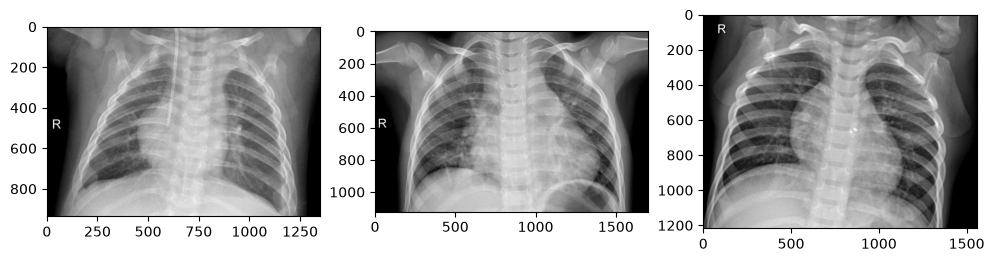

In [161]:
fig ,ax = plt.subplots(1,3,figsize=(12,12))
path = path_test.iloc[0]
img=Image.open(path)
ax[0].imshow(img ,cmap="gray")

path = path_test.iloc[1]
img=Image.open(path)
ax[1].imshow(img ,cmap="gray")

path = path_test.iloc[2]
img=Image.open(path)
ax[2].imshow(img ,cmap="gray")


plt.show()

FP・FNともに目視での明確な視覚的特徴は確認できなかった。誤分類の原因は画像の異常というより、Baseline CNN(Conv+Pool1セットのみ)の表現力不足によるものと推測される。より深いモデル(ResNet18, EfficientNet-B0)でこれらの画像が正しく分類できるか、今後比較する。

In [162]:
from torchvision import models
model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

In [163]:
print(model.parameters())

<generator object Module.parameters at 0x11dc5fd80>


In [164]:
import torch.nn as nn 

In [165]:
for param in model.parameters():
     param.requires_grad = False
model.fc = nn.Linear(in_features=512, out_features=2)

In [166]:
model.fc

Linear(in_features=512, out_features=2, bias=True)

In [167]:
for p in model.parameters():
    print(p.requires_grad)

False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
True
True


In [168]:
def resnet_train(model,dataset,epoch_num=3):
    TP = FP = FN = TN =0
    mean_list = []
    for epoch in range(epoch_num):
        loss_list= []
        for images , labels in dataset :
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs ,labels)
            loss.backward()
            optimizer.step()
            loss_value = loss.item()
            loss_list.append(loss_value)
            pred_label = torch.argmax(outputs, dim=1)
            TP += ((pred_label == 1) & (labels == 1)).sum().item()
            FP += ((pred_label == 1) & (labels == 0)).sum().item()
            FN += ((pred_label == 0) & (labels == 1)).sum().item()
            TN += ((pred_label == 0) & (labels == 0)).sum().item()            
        mean_loss = np.mean(loss_list)
        mean_list.append(mean_loss)
        print(f"epoch {epoch}: mean_loss = {mean_loss}")
    accuracy = (TP + TN) / (TP +FP + FN +TN)
    precision = TP /(TP +FP) 
    recall = TP /(TP +FN)
    F1 = 2 * precision *recall /(recall +precision)
    return accuracy ,precision , recall ,F1 

In [169]:
acc , precision , recall , F1= resnet_train(model,train_data )

epoch 0: mean_loss = 0.6360308566342102
epoch 1: mean_loss = 0.6372529548004361
epoch 2: mean_loss = 0.6371661821391685


In [173]:

OUTPUTS_DIR =Path("..") / "outputs" / "models"
OUTPUTS_DIR.mkdir(parents=True, exist_ok=True)
save_path = OUTPUTS_DIR / "ResNet18.pth"
torch.save(model.state_dict(), save_path)

In [170]:
print(f"accuracy : {acc}")

print(f"precision : {precision}")

print(f"recall :{recall}")

print(f"F1 : {F1}")

accuracy : 0.6775306748466258
precision : 0.733082973145327
recall :0.889978494623656
F1 : 0.8039474706659415


In [174]:
test_acc , tets_precision , test_recall , test_F1 = calc_test(model,test_data)

[[357  23  33 211]]
epoch 0: mean_loss = 0.6838776813103602
epoch 1: mean_loss = 0.6838776813103602
epoch 2: mean_loss = 0.6838776813103602


In [175]:
print(f"accuracy : {test_acc}")

print(f"precision : {tets_precision}")

print(f"recall :{test_recall}")

print(f"F1 : {test_F1}")

accuracy : 0.6089743589743589
precision : 0.6285211267605634
recall :0.9153846153846154
F1 : 0.7453027139874738


In [ ]:
val_acc , val_precision , val_recall , val_F1 = calc_test(model,val_data)

[[6 0 2 8]]
epoch 0: mean_loss = 0.874737560749054
epoch 1: mean_loss = 0.874737560749054
epoch 2: mean_loss = 0.874737560749054


In [ ]:
print(f"accuracy : {val_acc}")

print(f"precision : {val_precision}")

print(f"recall :{val_recall}")

print(f"F1 : {val_F1}")

accuracy : 0.375
precision : 0.42857142857142855
recall :0.75
F1 : 0.5454545454545454


## BaseLineCNNとResNet18　モデル比較結果
BaseLineCNNの方が精度が良い


仮説：
凍結されたパラメータを使っていないので、表現力の違いによって精度が立たなくなっている

In [ ]:
resnet_test_accuracy , resnet_test_prescision, resnet_test_recall ,resnet_test_F1 , resnet_test_false_detictt = calc_test_false_detecit(model,test_data)

[[369  14  21 220]]
epoch 0: mean_loss = 0.687753846247991


In [ ]:
resnet_test_tensor = torch.cat(resnet_test_false_detictt)

In [ ]:
resnet_test_index = resnet_test_tensor.tolist()
test_path = test_df.iloc[resnet_test_index]["path"]

In [ ]:
test_path


0                   data/test/NORMAL/IM-0031-0001.jpeg
1                   data/test/NORMAL/IM-0025-0001.jpeg
2           data/test/NORMAL/NORMAL2-IM-0272-0001.jpeg
3           data/test/NORMAL/NORMAL2-IM-0102-0001.jpeg
4           data/test/NORMAL/NORMAL2-IM-0229-0001.jpeg
                            ...                       
229         data/test/NORMAL/NORMAL2-IM-0309-0001.jpeg
230    data/test/NORMAL/NORMAL2-IM-0246-0001-0001.jpeg
231         data/test/NORMAL/NORMAL2-IM-0292-0001.jpeg
232         data/test/NORMAL/NORMAL2-IM-0221-0001.jpeg
233         data/test/NORMAL/NORMAL2-IM-0198-0001.jpeg
Name: path, Length: 220, dtype: object

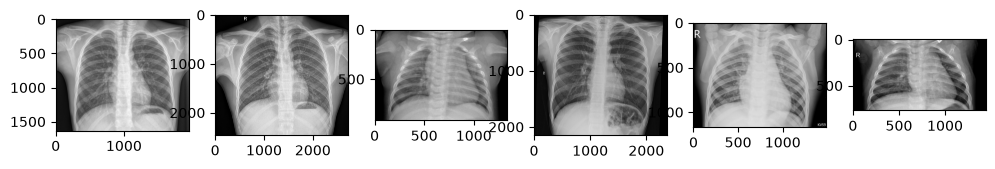

In [ ]:
fig  , ax  = plt.subplots(1,6 ,figsize= (12,12))
for i in range(6):
    path = test_path.iloc[i]
    img = Image.open(path)
    ax[i].imshow(img, cmap= "gray")

plt.show()

目視で明確な視覚的特徴は見つからなかった。

見落としの方も確認する

In [ ]:
resnet_test_accuracy , resnet_test_prescision, resnet_test_recall ,resnet_test_F1 , resnet_test_false_detictt = calc_test_false_detecit2(model,test_data)

[[369  14  21 220]]
epoch 0: mean_loss = 0.687753846247991


In [ ]:
resnet_tensor_2  = torch.cat(resnet_test_false_detictt)
resnet_test_index = resnet_tensor_2.tolist()

In [ ]:
test_path = test_df.iloc[resnet_test_index]["path"]

In [ ]:
test_path

15     data/test/PNEUMONIA/person134_bacteria_640.jpeg
51      data/test/PNEUMONIA/person1623_virus_2813.jpeg
67     data/test/PNEUMONIA/person117_bacteria_557.jpeg
83     data/test/PNEUMONIA/person134_bacteria_641.jpeg
90      data/test/PNEUMONIA/person81_bacteria_398.jpeg
131         data/test/PNEUMONIA/person21_virus_52.jpeg
135    data/test/PNEUMONIA/person175_bacteria_834.jpeg
176        data/test/PNEUMONIA/person65_virus_123.jpeg
180        data/test/PNEUMONIA/person52_virus_106.jpeg
189    data/test/PNEUMONIA/person152_bacteria_722.jpeg
193     data/test/PNEUMONIA/person1618_virus_2805.jpeg
202     data/test/PNEUMONIA/person1673_virus_2889.jpeg
221     data/test/PNEUMONIA/person1637_virus_2834.jpeg
259     data/test/PNEUMONIA/person1608_virus_2786.jpeg
276         data/test/PNEUMONIA/person32_virus_71.jpeg
280        data/test/PNEUMONIA/person54_virus_109.jpeg
305        data/test/PNEUMONIA/person51_virus_105.jpeg
343        data/test/PNEUMONIA/person75_virus_136.jpeg
347     da

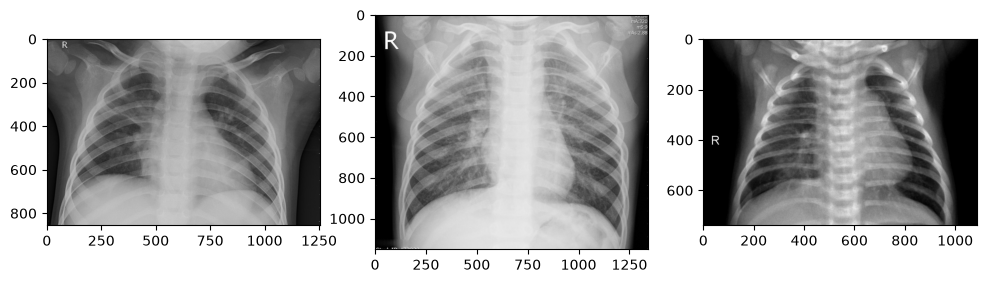

In [ ]:
fig ,ax = plt.subplots(1,3 ,figsize=(12,12))
path = test_path.iloc[0]
img = Image.open(path)
ax[0].imshow(img,cmap="gray")


path = test_path.iloc[1]
img = Image.open(path)
ax[1].imshow(img,cmap="gray")


path = test_path.iloc[2]
img = Image.open(path)
ax[2].imshow(img,cmap="gray")

plt.show()

## EfficientB0モデルの実装

In [ ]:
model= models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.DEFAULT)

In [ ]:
def efficienr_train(model,dataset,epoch_num=3):
    TP = FP = FN = TN =0
    mean_list = []
    model.train()
    for epoch in range(epoch_num):
        loss_list= []
        for images , labels in dataset :
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs ,labels)
            loss.backward()
            optimizer.step()
            loss_value = loss.item()
            loss_list.append(loss_value)
            pred_label = torch.argmax(outputs, dim=1)
            TP += ((pred_label == 1) & (labels == 1)).sum().item()
            FP += ((pred_label == 1) & (labels == 0)).sum().item()
            FN += ((pred_label == 0) & (labels == 1)).sum().item()
            TN += ((pred_label == 0) & (labels == 0)).sum().item()            
        mean_loss = np.mean(loss_list)
        mean_list.append(mean_loss)
        print(f"epoch {epoch}: mean_loss = {mean_loss}")
    accuracy = (TP + TN) / (TP +FP + FN +TN)
    precision = TP /(TP +FP) 
    recall = TP /(TP +FN)
    F1 = 2 * precision *recall /(recall +precision)
    return accuracy ,precision , recall ,F1 

In [ ]:
def effcient_test(model,dataset,epoch_num=3):
    mean_list = []
    TP = FP = FN = TN =0
    mat_list = []
    model.eval()
    for epoch in range(epoch_num):
        loss_list= []
        for images , labels in dataset :
            outputs = model(images)
            pred_label = torch.argmax(outputs, dim=1)
            loss = criterion(outputs ,labels)
            loss_value = loss.item()
            loss_list.append(loss_value)
            TP += ((pred_label == 1) & (labels == 1)).sum().item()
            FP += ((pred_label == 1) & (labels == 0)).sum().item()
            FN += ((pred_label == 0) & (labels == 1)).sum().item()
            TN += ((pred_label == 0) & (labels == 0)).sum().item()
        if epoch ==0 :    
            mat_list.append((TP,TN,FN,FP))
            conf_mat = np.array(mat_list)
            print(conf_mat)
        mean_loss = np.mean(loss_list)
        mean_list.append(mean_loss)
        print(f"epoch {epoch}: mean_loss = {mean_loss}")
    accuracy = (TP + TN) / (TP +FP + FN +TN)
    precision = TP /(TP +FP) 
    recall = TP /(TP +FN)
    F1 = 2 * precision *recall /(recall +precision)
    return accuracy ,precision , recall ,F1

In [ ]:
def effcient_test_1(model,dataset,epoch_num=1):
    mean_list = []
    TP = FP = FN = TN =0
    mat_list = []
    false_detect = []
    model.eval()
    for epoch in range(epoch_num):
        loss_list= []
        for i , (images , labels) in enumerate(dataset):
            outputs = model(images)
            pred_label = torch.argmax(outputs, dim=1)
            local_idx = torch.where((pred_label == 1) & (labels == 0))[0]
            global_idx = i * 16  + local_idx            
            loss = criterion(outputs ,labels)
            loss_value = loss.item()
            loss_list.append(loss_value)
            TP += ((pred_label == 1) & (labels == 1)).sum().item()
            FP += ((pred_label == 1) & (labels == 0)).sum().item()
            FN += ((pred_label == 0) & (labels == 1)).sum().item()
            TN += ((pred_label == 0) & (labels == 0)).sum().item()
            false_detect.append(global_idx)
        if epoch ==0 :    
            mat_list.append((TP,TN,FN,FP))
            conf_mat = np.array(mat_list)
            print(conf_mat)
        mean_loss = np.mean(loss_list)
        mean_list.append(mean_loss)
        print(f"epoch {epoch}: mean_loss = {mean_loss}")
    accuracy = (TP + TN) / (TP +FP + FN +TN)
    precision = TP /(TP +FP) 
    recall = TP /(TP +FN)
    F1 = 2 * precision *recall /(recall +precision)
    return accuracy ,precision , recall ,F1 ,false_detect

In [ ]:
## FNの誤分類を確認する
def effcient_test_2(model,dataset,epoch_num=1):
    mean_list = []
    TP = FP = FN = TN =0
    mat_list = []
    false_detect = []
    model.eval()
    for epoch in range(epoch_num):
        loss_list= []
        for i , (images , labels) in enumerate(dataset):
            outputs = model(images)
            pred_label = torch.argmax(outputs, dim=1)
            local_idx = torch.where((pred_label == 0) & (labels == 1))[0]
            global_idx = i * 16  + local_idx            
            loss = criterion(outputs ,labels)
            loss_value = loss.item()
            loss_list.append(loss_value)
            TP += ((pred_label == 1) & (labels == 1)).sum().item()
            FP += ((pred_label == 1) & (labels == 0)).sum().item()
            FN += ((pred_label == 0) & (labels == 1)).sum().item()
            TN += ((pred_label == 0) & (labels == 0)).sum().item()
            false_detect.append(global_idx)
        if epoch ==0 :    
            mat_list.append((TP,TN,FN,FP))
            conf_mat = np.array(mat_list)
            print(conf_mat)
        mean_loss = np.mean(loss_list)
        mean_list.append(mean_loss)
        print(f"epoch {epoch}: mean_loss = {mean_loss}")
    accuracy = (TP + TN) / (TP +FP + FN +TN)
    precision = TP /(TP +FP) 
    recall = TP /(TP +FN)
    F1 = 2 * precision *recall /(recall +precision)
    return accuracy ,precision , recall ,F1 ,false_detect

In [ ]:
print(model)

EfficientNet(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (2): SiLU(inplace=True)
    )
    (1): Sequential(
      (0): MBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
            (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
            (2): SiLU(inplace=True)
          )
          (1): SqueezeExcitation(
            (avgpool): AdaptiveAvgPool2d(output_size=1)
            (fc1): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
            (fc2): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
            (activation): SiLU(inplace=True)
            (scale_activation): Sigmoid()
          )
          

In [ ]:
for param in model.parameters():
    param.requires_grad = False
    print(param.requires_grad)


False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
Fals

In [ ]:
model.classifier[1] = nn.Linear(in_features=1280 , out_features=2)

In [ ]:
print(model)

EfficientNet(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (2): SiLU(inplace=True)
    )
    (1): Sequential(
      (0): MBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
            (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
            (2): SiLU(inplace=True)
          )
          (1): SqueezeExcitation(
            (avgpool): AdaptiveAvgPool2d(output_size=1)
            (fc1): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
            (fc2): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
            (activation): SiLU(inplace=True)
            (scale_activation): Sigmoid()
          )
          

In [ ]:
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [ ]:
for param in model.parameters():
    print(param.requires_grad)

False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
Fals

In [ ]:
acc , precision , recall , F1= efficienr_train(model,train_data )

epoch 0: mean_loss = 0.2648081205031075
epoch 1: mean_loss = 0.2006086866411329
epoch 2: mean_loss = 0.1901774746965777


In [ ]:
test_acc , test_precision , test_recall , test_F1 = effcient_test(model,test_data)

[[352 199  38  35]]
epoch 0: mean_loss = 0.3059385686348646
epoch 1: mean_loss = 0.3059385686348646
epoch 2: mean_loss = 0.3059385686348646


In [ ]:
print(test_acc)

0.8830128205128205


In [ ]:
val_acc , val_precision , val_recall , val_F1 = effcient_test(model,val_data)

[[8 8 0 0]]
epoch 0: mean_loss = 0.17487239837646484
epoch 1: mean_loss = 0.17487239837646484
epoch 2: mean_loss = 0.17487239837646484


In [ ]:
test_acc_2 , test_precision_2 , test_recall_2 , test_F1_2, test_false_detict_2 = effcient_test_2(model,test_data)

[[352 199  38  35]]
epoch 0: mean_loss = 0.3059385686348646


In [ ]:
test_acc_1   , test_precision_1    , test_recall_1 , test_F1_1, test_false_detict_1 = effcient_test_1(model,test_data)

[[352 199  38  35]]
epoch 0: mean_loss = 0.3059385686348646


In [ ]:
efficient_tensor_2 = torch.cat(test_false_detict_2)
efficient_test_path_2 = test_df.iloc[efficient_tensor_2]["path"]

In [ ]:
efficient_tensor_1 = torch.cat(test_false_detict_1)
efficient_test_path_1 = test_df.iloc[efficient_tensor_1]["path"]

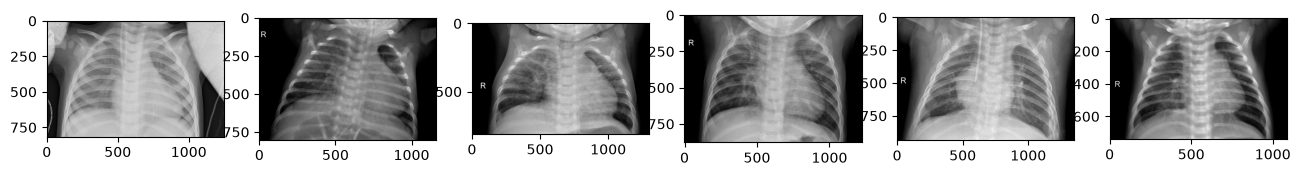

In [ ]:
fig ,ax = plt.subplots(1,6,figsize=(16,16))

for i in range(6):
    path = efficient_test_path_2.iloc[i]
    img = Image.open(path)

    ax[i].imshow(img,cmap= "gray")

plt.show()

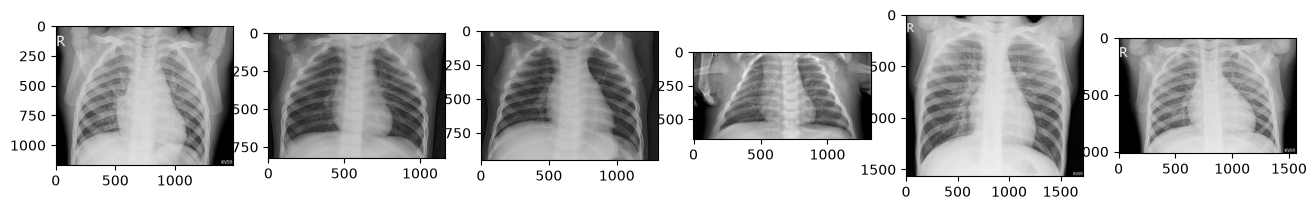

In [ ]:
fig ,ax = plt.subplots(1,6,figsize=(16,16))

for i in range(6):
    path = efficient_test_path_1.iloc[i]
    img = Image.open(path)

    ax[i].imshow(img,cmap= "gray")

plt.show()

ResNet18よりもEfficientNet-B0の方がBackBoneを凍結した状況下での精度は良かった。

BackBoneの質が良かったからEfficientNet-B0の高い精度がでた。

ResNet18では、今回のようなBackBoneを固定した状況では、精度が出ないのでBackBoneをファインチューニングした場合での二つのモデルを比較する必要がある。

In [ ]:
def model_params_count(model):
    count_p = 0
    for p in model.parameters():
        count_p += p.numel()
    return print(count_p)

In [ ]:
# Effcient-B0のパラメータの個数
model_params_count(model)

4010110


In [ ]:
# BaseLineCNNのパラメータの個数
baseline_model = BaselineCNN()
model_params_count(baseline_model)

21962


In [ ]:
# ResNet18のパラメータの個数
resnet_model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
for param in resnet_model.parameters():
     param.requires_grad = False
resnet_model.fc = nn.Linear(in_features=512, out_features=2)
model_params_count(resnet_model)

11177538


In [ ]:
import time
def mesuare_interface_time(model , data):
    start_time = time.time()
    for images , labels in data :
        with torch.no_grad():
            outputs = model(images)
    end_time = time.time()
    return print(f"処理時間 :{end_time - start_time}")
    

In [ ]:
# BaseLineの１バッチあたりの処理時間を計測
mesuare_interface_time(baseline_model,train_data)

処理時間 :56.82280373573303


In [ ]:
# ResNet18の１バッチあたりの処理時間を計測
mesuare_interface_time(resnet_model,train_data)

処理時間 :272.0668978691101


In [ ]:
# Efficient-B0の１バッチあたりの処理時間を計測
mesuare_interface_time(model,train_data)

処理時間 :884.2012250423431


| モデル | accuracy | recall | precision | F1 | パラメータ数|１回あたりの推論の処理時間|
|---|---|---|---|---|---|---|
| BaseLineCNN |0.80|0.98|0.76|0.8|21962|59.9s|
| ResNet18 |0.60| 0.82|0.64|0.76|11177538|332.1s|
| Efficient-B0 |0.89|0.94|0.89|0.94|4010110|969.0s|

今回は医療画像で肺炎患者の検出ということで、recallと処理時間が一番重要と考えた。それを踏まえると、
BaseLinCNNがrecallが約98%として、見落としの患者が少ない結果になった。また、推論の処理時間に関しても、3モデルの中では一番少ない結果になっている。
Precisionがあまり高くない分正常な患者を陽性患者と診断しやすくなる。
これは、第一スクリーニングとして用いることによって、陽性と判断された患者を第二次で精密検査を行うことによって適正な診断をするというプロセスにする。

### Fine TuningをしてResNet18 Efficient-B0の精度を比較する

部分的にBackBoneを凍結を解除する

In [ ]:
resnet_model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
for param in resnet_model.parameters():
     param.requires_grad = False
for p in resnet_model.layer4.parameters():
     p.requires_grad = True
resnet_model.fc = nn.Linear(in_features=512, out_features=2)

In [ ]:
for p in resnet_model.parameters():
    print(p.requires_grad)

False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True


In [ ]:
optimizer = torch.optim.Adam([
    {"params": resnet_model.layer4.parameters(), "lr": 0.0001},
    {"params": resnet_model.fc.parameters(), "lr": 0.001},
])

In [ ]:
acc , precision , recall , F1= resnet_train(resnet_model,train_data )

epoch 0: mean_loss = 0.16416854405221443
epoch 1: mean_loss = 0.10998281721451371
epoch 2: mean_loss = 0.09019827718940775


In [ ]:
Normal_ResNet_train_acc , Normal_ResNet_train_precision , Normal_ResNet_train_recall , F1= calc_test(resnet_model,train_data )

[[3741 1311  134   30]]
epoch 0: mean_loss = 0.07839313150898473
epoch 1: mean_loss = 0.0848264020354847
epoch 2: mean_loss = 0.09017623099748422


In [ ]:
Normal_ResNet_train_acc 

0.9661937627811861

In [ ]:
resnet_test_acc , resnet_test_precision , resnet_test_recall , resnet_test_F1=calc_test(resnet_model,test_data) 

[[337  55  53 179]]
epoch 0: mean_loss = 2.9763374388791046
epoch 1: mean_loss = 2.9763374388791046
epoch 2: mean_loss = 2.9763374388791046


In [ ]:
print(f"acc :{resnet_test_acc}",
      f"precision :{resnet_test_precision}",
      f"recall :{resnet_test_recall}",
      f"F1 :{resnet_test_F1}")

acc :0.6282051282051282 precision :0.6531007751937985 recall :0.8641025641025641 F1 :0.7439293598233996


In [ ]:
resnet_val_acc , resnet_val_precision , resnet_val_recall , resnet_val_F1=calc_test(resnet_model,val_data) 

[[8 3 0 5]]
epoch 0: mean_loss = 0.6954976916313171
epoch 1: mean_loss = 0.6954976916313171
epoch 2: mean_loss = 0.6954976916313171


In [ ]:
resnet_test_acc

0.6586538461538461

### ResNet18のパラメータの一部を開放
訓練スコアは9割であったのに、テストのスコアは6割りという過学習に近い状況に陥った。


Transforms.Composeにガウシアンノイズを加えて過学習を防ぐ工夫を取り入れる。

### ガウシアンのウイズを加えたもので、テストの精度が上がるのか確認をする

In [ ]:
def add_noise(tensor):
    noise = torch.randn_like(tensor) * 0.05  # 0.05はノイズの強さ(標準偏差)
    return tensor + noise

In [ ]:
train_transfromers  = transforms.Compose([transforms.Resize((224,224)),transforms.RandomAffine(degrees=10, 
translate=(0.1, 0.1), scale=(0.9, 1.1)),transforms.ColorJitter(brightness=0.1, contrast=0.1),
transforms.ToTensor(),
transforms.Lambda(add_noise),
transforms.Normalize((norm_mean ,norm_mean,norm_mean), (norm_std,norm_std,norm_std))])

In [ ]:
train_datasets = My_Dataset(train_df, train_transfromers)
train_data = DataLoader(train_datasets, 16, shuffle=True)


In [ ]:
resnet_model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
for param in resnet_model.parameters():
     param.requires_grad = False
for p in resnet_model.layer4.parameters():
     p.requires_grad = True
resnet_model.fc = nn.Linear(in_features=512, out_features=2)

In [ ]:
optimizer = torch.optim.Adam([
    {"params": resnet_model.layer4.parameters(), "lr": 0.0001},
    {"params": resnet_model.fc.parameters(), "lr": 0.001},
])

In [ ]:
Gauss_acc , Gauss_precision , Gauss_recall , Gauss_F1 = resnet_train(resnet_model,train_data )

epoch 0: mean_loss = 0.15207008484528153
epoch 1: mean_loss = 0.10497711032437607
epoch 2: mean_loss = 0.09896974766732657


In [ ]:
resnet_test_acc , resnet_test_precision , resnet_test_recall , resnet_test_F1=calc_test(resnet_model,test_data) 

[[354  44  36 190]]
epoch 0: mean_loss = 3.4295035081031995
epoch 1: mean_loss = 3.4295035081031995
epoch 2: mean_loss = 3.4295035081031995


In [ ]:
resnet_val_acc , resnet_val_precision , resnet_val_recall , resnet_val_F1=calc_test(resnet_model,val_data) 

[[8 3 0 5]]
epoch 0: mean_loss = 0.5112413167953491
epoch 1: mean_loss = 0.5112413167953491
epoch 2: mean_loss = 0.5112413167953491


In [ ]:
resnet_test_acc

0.6378205128205128

In [ ]:
resnet_test_acc

0.6378205128205128

In [ ]:
print(f"accuracy :{resnet_test_acc}",
      f"precision:{resnet_test_precision}",
      f"recall :{resnet_test_recall}",
      f" F1 : {resnet_test_F1}")

accuracy :0.6378205128205128 precision:0.6507352941176471 recall :0.9076923076923077  F1 : 0.7580299785867238


In [ ]:
resnet_train_acc , resnet_train_precision , resnet_train_recall , resnet_train_F1=calc_test(resnet_model,train_data) 

[[3804 1255   71   86]]
epoch 0: mean_loss = 0.0795187097884846
epoch 1: mean_loss = 0.06840548285624538
epoch 2: mean_loss = 0.08221673416409447


In [ ]:
print(resnet_train_acc)

0.971881390593047


### ガウシアンノイズの結果まとめ

##### ResNet18- finetuningモデルでガウシアンノイズの有無によるモデルに対する過学習に対する効果を比較

ノイズなしの場合:
学習後
Train data予測率:96.6% 
Test data予測率: 59.8%
差：36.8%
ノイズありの場合:
学習後
Train data予測率:97.2% 
Test data予測率: 63.8%
差：33.4%
精度の差は小さくなった。
ガウシアンノイズによって、過学習を押さえ込む働きをしたが,layer4のパラメータ数が訓練データよりも多いというボトルネックの解消までは至らなかった。